In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import ast
import os

In [2]:
BASE_PATH = 'dataset'
OUTPUT_PIPELINE = os.path.join(BASE_PATH, 'output_pipeline')
METRICS_FOLDER = os.path.join(OUTPUT_PIPELINE, 'metrics_model_comparison')
LR = os.path.join(OUTPUT_PIPELINE, "linear_regression")
RF = os.path.join(OUTPUT_PIPELINE, 'random_forest')
XGB = os.path.join(OUTPUT_PIPELINE, 'xgboost')

os.makedirs(METRICS_FOLDER, exist_ok=True)

In [3]:
lr_metrics = pd.read_csv(os.path.join(LR, "linear_regression_metrics.csv"))
rf_metrics = pd.read_csv(os.path.join(RF, "random_forest_metrics.csv"))
xgb_metrics = pd.read_csv(os.path.join(XGB, "xgboost_metrics.csv"))

In [4]:
# gabungkan semua metrics
baseline_metrics = pd.concat([
    lr_metrics,
    rf_metrics,
    xgb_metrics,
], ignore_index=True)

print("BASELINE MODEL COMPARISON")
baseline_metrics

BASELINE MODEL COMPARISON


,model,train_mae,train_rmse,train_r2,val_mae,val_rmse,val_r2
0,Linear Regression,"[18820.796426068493, 18505.793081046777, 18749...","[32815.35312704448, 32022.766377380176, 33566....","[0.9769585708311023, 0.9776729017285349, 0.976...","[18103.81063106512, 20095.448293210793, 18038....","[33183.030430368024, 36295.11285256476, 30024....","[0.9759682450711444, 0.9731360220424613, 0.978..."
1,Random Forest,"[4812.870929509904, 4979.021087101926, 4879.00...","[9366.615239783032, 10539.828456998339, 10183....","[0.9981227564947857, 0.9975813018358802, 0.997...","[14364.757044781925, 13487.728055254616, 13979...","[37059.92396238926, 27862.97885536348, 26391.8...","[0.9700247755502761, 0.9841682431570812, 0.983..."
2,XGBoost,"[9028.714114443435, 8783.608235995092, 8717.63...","[14527.523964351863, 14183.353150466344, 14020...","[0.9954841609989022, 0.9956200170191505, 0.995...","[15206.665550723992, 13159.18772958452, 14503....","[36591.34772576301, 23016.966036385707, 25385....","[0.9707779817841923, 0.9891963582623076, 0.984..."


In [5]:
kolom_target = "val_rmse"

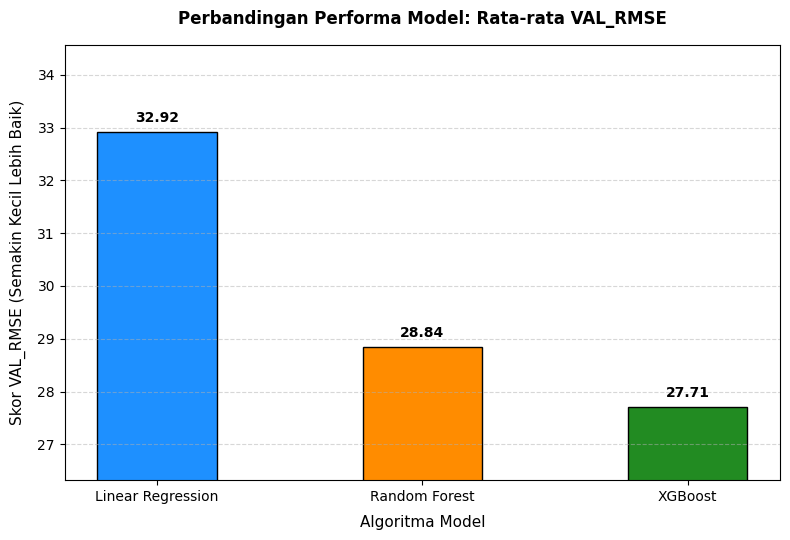

In [6]:
baseline_metrics["plot_value"] = baseline_metrics[kolom_target].apply(
    lambda x: np.mean(ast.literal_eval(x)) / 1000 if isinstance(x, str) else x / 1000
)

fig, ax = plt.subplots(figsize=(8, 5.5))
warna = ["dodgerblue", "darkorange", "forestgreen"]

bars = ax.bar(
    baseline_metrics["model"], 
    baseline_metrics["plot_value"], 
    color=warna, edgecolor="black", width=0.45
)

ax.bar_label(bars, fmt='%.2f', padding=5, fontweight='bold', fontsize=10)

ax.set_title(f"Perbandingan Performa Model: Rata-rata {kolom_target.upper()}", fontsize=12, fontweight="bold", pad=15)
ax.set_ylabel(f"Skor {kolom_target.upper()} (Semakin Kecil Lebih Baik)", fontsize=11, labelpad=8)
ax.set_xlabel("Algoritma Model", fontsize=11, labelpad=8)

ymin, ymax = baseline_metrics["plot_value"].min(), baseline_metrics["plot_value"].max()
ax.set_ylim(ymin * 0.95, ymax * 1.05)

ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(
    os.path.join(METRICS_FOLDER, "model_comparison.png"),
    dpi=300, 
    bbox_inches='tight'
)
plt.show()

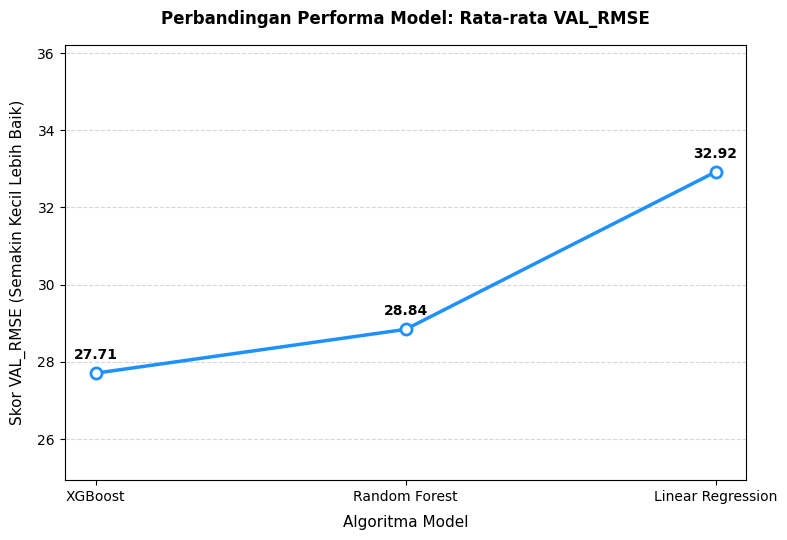

In [7]:
df_plot = baseline_metrics.sort_values(by="plot_value")

fig, ax = plt.subplots(figsize=(8, 5.5))

ax.plot(
    df_plot["model"], 
    df_plot["plot_value"], 
    marker='o',
    linestyle='-',
    color='dodgerblue', 
    linewidth=2.5, 
    markersize=8, 
    markerfacecolor='white', 
    markeredgewidth=2
)

for i, txt in enumerate(df_plot["plot_value"]):
    ax.annotate(f'{txt:.2f}', 
                (df_plot["model"].iloc[i], df_plot["plot_value"].iloc[i]), 
                textcoords="offset points", 
                xytext=(0, 10), 
                ha='center', 
                fontweight='bold', 
                fontsize=10)

ax.set_title(f"Perbandingan Performa Model: Rata-rata {kolom_target.upper()}", fontsize=12, fontweight="bold", pad=15)
ax.set_ylabel(f"Skor {kolom_target.upper()} (Semakin Kecil Lebih Baik)", fontsize=11, labelpad=8)
ax.set_xlabel("Algoritma Model", fontsize=11, labelpad=8)

ymin, ymax = df_plot["plot_value"].min(), df_plot["plot_value"].max()
ax.set_ylim(ymin * 0.9, ymax * 1.1)

ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(
    os.path.join(METRICS_FOLDER, "model_comparison_line_chart.png"),
    dpi=300, 
    bbox_inches='tight'
)
plt.show()

In [8]:
# simpan hasil akhir
baseline_metrics.to_csv(
    os.path.join(METRICS_FOLDER, 'baseline_metrics_comparison.csv'),
    index=False
)

print("Berkas berhasil disimpan!")

Berkas berhasil disimpan!
